# dragon


In [13]:
from pathlib import Path
import sys, time

import matplotlib.pyplot as plt
import numpy as np
import mitsuba as mi
import drjit as dr

mi.set_variant('cuda_ad_rgb')
from mitsuba import ScalarTransform4f as T
from gpytoolbox import remesh_botsch

folder = Path.cwd()
if not (folder / 'data').exists():
    folder = folder / '4d_mesh'
sys.path.insert(0, str(folder.parent))
sys.path.insert(0, str(folder))

from filters import laplacian_smoothing_filter, cross_bilateral_filter
from optimizers import spatiotemporal_mesh_optimizer

In [14]:
cube = folder / 'data' / 'cube'
dragon_ply = str(folder / 'data' / 'asian_dragon' / 'xyzrgb_dragon.ply')
sensor_count, render_res = 25, 256

golden = (1 + 5 ** 0.5) / 2
sensors = []
for i in range(sensor_count):
    theta = 2 * np.pi * i / golden
    phi = np.arccos(1 - 2 * (i + 0.5) / sensor_count)
    origin = [3.5 * np.cos(theta) * np.sin(phi), 3.5 * np.sin(theta) * np.sin(phi), 3.5 * np.cos(phi)]
    sensors.append(mi.load_dict({
        'type': 'perspective', 'fov': 45,
        'to_world': T.look_at(target=[0, 0, 0], origin=origin, up=[0, 1, 0]),
        'film': {'type': 'hdrfilm', 'width': render_res, 'height': render_res,
                 'filter': {'type': 'gaussian'}, 'sample_border': True},
        'sampler': {'type': 'independent', 'sample_count': 16}}))

material = {'type': 'twosided', 'material': {'type': 'diffuse'}}
scene_dict = {
    'type': 'scene',
    'integrator': {'type': 'direct_projective', 'sppi': 0, 'sppc': 1, 'sppp': 1},
    'emitter': {'type': 'envmap', 'filename': str(cube / 'envmap.exr')},
    'shape': {'type': 'ply', 'filename': str(cube / 'ico_10k.ply'),
              'face_normals': False, 'bsdf': material}}

raw = np.array(mi.traverse(mi.load_dict({'type': 'scene', 'shape': {'type': 'ply', 'filename': dragon_ply}}))['shape.vertex_positions']).reshape(-1, 3)
center = raw.mean(0)
scale = 2.0 / (raw.max(0) - raw.min(0)).max()
to_world = T.scale(float(scale)).translate((-center).tolist())

target = dict(scene_dict)
target['shape'] = {'type': 'ply', 'filename': dragon_ply, 'to_world': to_world,
                   'face_normals': False, 'bsdf': material}
target_scene = mi.load_dict(target)
reference = [mi.render(target_scene, sensor=s, spp=64, seed=0) for s in sensors]

_tp = mi.traverse(target_scene)
target_v = np.array(_tp['shape.vertex_positions']).reshape(-1, 3)
target_f = np.array(_tp['shape.faces']).reshape(-1, 3)

scene = mi.load_dict(scene_dict)
params = mi.traverse(scene)

In [15]:
def average_edge_length(v, f):
    e = np.concatenate([f[:, [0, 1]], f[:, [1, 2]], f[:, [2, 0]]])
    return np.linalg.norm(v[e[:, 0]] - v[e[:, 1]], axis=1).mean()


def remesh(v, f, ratio=0.5):
    h = average_edge_length(v, f) * ratio
    v2, f2 = remesh_botsch(v.astype(np.double), f.astype(np.int32), 5, float(h), True)
    return v2, f2.astype(int)


def normals(v, f):
    tri = v[f]
    fn = np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0])
    vn = np.zeros_like(v)
    for k in range(3):
        np.add.at(vn, f[:, k], fn)
    return vn / np.maximum(np.linalg.norm(vn, axis=1, keepdims=True), 1e-12)


def grad(v, f, sensor_idx, seed):
    pos = mi.Float(v.astype(np.float32).ravel())
    dr.enable_grad(pos)
    params['shape.vertex_positions'] = pos
    params['shape.faces'] = mi.Int(f.astype(np.int32).ravel())
    params.update()
    img = mi.render(scene, params, sensor=sensors[sensor_idx], seed=seed)
    loss = dr.mean(dr.abs(img - reference[sensor_idx]))
    dr.backward(loss)
    g = np.array(dr.grad(pos)).reshape(-1, 3)
    dr.sync_thread()  
    return g, float(np.array(loss))


def render(v, f, sensor_idx=0):
    params['shape.vertex_positions'] = mi.Float(v.astype(np.float32).ravel())
    params['shape.faces'] = mi.Int(f.astype(np.int32).ravel())
    params.update()
    return np.array(mi.render(scene, sensor=sensors[sensor_idx], spp=128, seed=0))


def make_filters(f, num):
    return laplacian_smoothing_filter(f, num, 19), cross_bilateral_filter(f, num, 19, 0.2, 0.16)


from scipy.spatial import cKDTree


def sample_surface(v, f, count=50000, seed=0):
    rng = np.random.default_rng(seed)
    tri = v[f]
    area = 0.5 * np.linalg.norm(np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0]), axis=1)
    idx = rng.choice(len(f), size=count, p=area / area.sum())
    a, b, c_ = tri[idx, 0], tri[idx, 1], tri[idx, 2]
    u, w = rng.random((count, 1)), rng.random((count, 1))
    flip = (u + w > 1).ravel(); u[flip], w[flip] = 1 - u[flip], 1 - w[flip]
    return a + u * (b - a) + w * (c_ - a)


def hausdorff(v, f):
    a = sample_surface(v, f)
    b = sample_surface(target_v, target_f)
    return max(cKDTree(b).query(a)[0].max(), cKDTree(a).query(b)[0].max())


def render_view(v, f, sensor):
    params['shape.vertex_positions'] = mi.Float(v.astype(np.float32).ravel())
    params['shape.faces'] = mi.Int(f.astype(np.int32).ravel())
    params.update()
    return np.array(mi.render(scene, sensor=sensor, spp=128, seed=0))

In [16]:
remesh_iters = [10, 30]
iterations = 50
snapshot_iters = [30, 50]

_v0 = np.array(params['shape.vertex_positions']).reshape(-1, 3)
_f0 = np.array(params['shape.faces']).reshape(-1, 3)
_v0, _inv0 = np.unique(_v0, axis=0, return_inverse=True)
_f0 = _inv0[_f0]


def run(postfilter_kind):
    v, f = _v0.copy(), _f0.copy()

    lap, bil = make_filters(f, len(v))
    post = lap if postfilter_kind == 'laplacian' else bil
    opt = spatiotemporal_mesh_optimizer(lr=1e-2, prefilter=lap, postfilter=post, b_1=0.9, b_2=0.99)
    lr_decay = 0.6 ** (1 / (iterations * sensor_count))

    losses, distances, snapshots = [], [], {}
    for it in range(iterations):
        if it in remesh_iters:
            v, f = remesh(v, f)
            lap, bil = make_filters(f, len(v))
            post = lap if postfilter_kind == 'laplacian' else bil
            opt = spatiotemporal_mesh_optimizer(lr=opt.lr, prefilter=lap, postfilter=post, b_1=0.9, b_2=0.99)

        n_hat = normals(v, f)
        total = 0.0
        for s in range(sensor_count):
            g, l = grad(v, f, s, it * sensor_count + s)
            v = opt.step(v, g, n_hat)
            opt.lr *= lr_decay
            total += l
        losses.append(total / sensor_count)
        distances.append(hausdorff(v, f))
        if (it + 1) in snapshot_iters:
            snapshots[it + 1] = (v.copy(), f.copy())
        if it % 5 == 0 or it in remesh_iters:
            print(f'  {postfilter_kind:9s} it {it:3d}  loss {losses[-1]:.5f}  haus {distances[-1]:.4f}  {len(v)} verts', flush=True)

    return {'v': v, 'f': f, 'losses': np.array(losses),
            'hausdorff': np.array(distances), 'snapshots': snapshots}


results = {}
for name, kind in [('large steps', 'laplacian'), ('cross-bilateral', 'bilateral')]:
    t = time.perf_counter()
    results[name] = run(kind)
    print(f'{name:16s} final loss {results[name]["losses"][-1]:.5f}'
          f'  {len(results[name]["v"])} verts  ({time.perf_counter()-t:.0f}s)')

  laplacian it   0  loss 0.11256  haus 0.9267  10242 verts
  laplacian it   5  loss 0.05131  haus 0.6466  10242 verts
  laplacian it  10  loss 0.02760  haus 0.4566  38464 verts
  laplacian it  15  loss 0.01763  haus 0.3478  38464 verts
  laplacian it  20  loss 0.01380  haus 0.3035  38464 verts
  laplacian it  25  loss 0.01181  haus 0.2747  38464 verts
  laplacian it  30  loss 0.01104  haus 0.2901  130980 verts
  laplacian it  35  loss 0.00947  haus 0.2980  130980 verts
  laplacian it  40  loss 0.00820  haus 0.3075  130980 verts
  laplacian it  45  loss 0.00756  haus 0.3080  130980 verts
large steps      final loss 0.00734  130980 verts  (182s)
  bilateral it   0  loss 0.11247  haus 0.9244  10242 verts
  bilateral it   5  loss 0.04977  haus 0.6337  10242 verts
  bilateral it  10  loss 0.02636  haus 0.4476  39028 verts
  bilateral it  15  loss 0.01774  haus 0.3645  39028 verts
  bilateral it  20  loss 0.01336  haus 0.3086  39028 verts
  bilateral it  25  loss 0.01145  haus 0.2741  39028 

[]

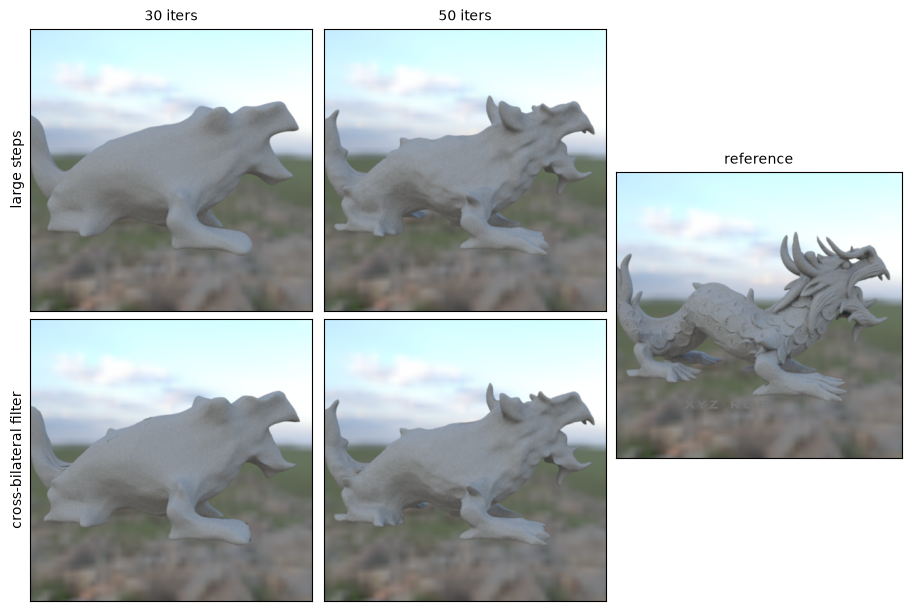

In [ ]:
zoom = mi.load_dict({
    'type': 'perspective', 'fov': 38,
    'to_world': T.look_at(target=[0.1, 0.05, 0], origin=[0.1, 0.15, 2.6], up=[0, 1, 0]),
    'film': {'type': 'hdrfilm', 'width': 400, 'height': 400,
             'filter': {'type': 'gaussian'}, 'sample_border': True},
    'sampler': {'type': 'independent', 'sample_count': 128}})

iters = [30, 50]
fig = plt.figure(figsize=(9, 6), layout='constrained')
gs = fig.add_gridspec(2, 3)
for row, name in enumerate(['large steps', 'cross-bilateral']):
    for col, it in enumerate(iters):
        v, f = results[name]['snapshots'][it]
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(np.clip(render_view(v, f, zoom) ** (1 / 2.2), 0, 1))
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f'{it} iters', fontsize=10)
        if col == 0:
            ax.set_ylabel('cross-bilateral filter' if name == 'cross-bilateral' else name, fontsize=10)
ax = fig.add_subplot(gs[:, 2])
ax.imshow(np.clip(np.array(mi.render(target_scene, sensor=zoom, spp=128, seed=0)) ** (1 / 2.2), 0, 1))
ax.set_title('reference', fontsize=10); ax.set_xticks([]); ax.set_yticks([])

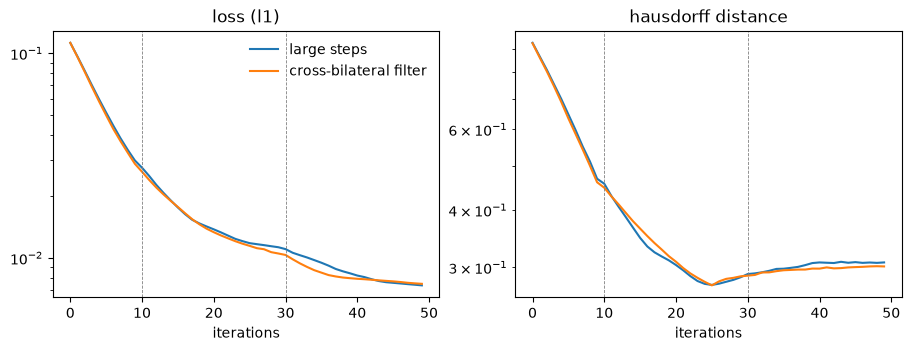

: 

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4), layout='constrained')
for a, (metric, label) in zip(ax, [('losses', 'loss (l1)'), ('hausdorff', 'hausdorff distance')]):
    a.plot(results['large steps'][metric], label='large steps')
    a.plot(results['cross-bilateral'][metric], label='cross-bilateral filter')
    for it in remesh_iters:
        a.axvline(it, color='gray', lw=0.6, ls='--')
    a.set_yscale('log'); a.set_xlabel('iterations'); a.set_title(label)
ax[0].legend(frameon=False)